### Step 1: Data Cleaning
A few notes on the decisions made:

- case dropped — it's a sequential row ID with no predictive value.
- Rows with missing age dropped — since age is your longevity target, you can't impute it without introducing bias into your regression labels.
- footlgth median-imputed — only 1 value missing, and median imputation is safer than mean when you're unsure about outliers in a biological measurement.
- Categorical encoding — sex and Pop are binary so simple integer mapping works fine; no need for one-hot encoding here.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load the dataset
df = pd.read_csv("possum.csv")

# Quick overview
print(f"Shape: {df.shape}")
df.head()

Shape: (104, 14)


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [11]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


In [12]:
# Summary statistics for numeric columns
df.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


In [13]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [14]:
# 'case' is just a row index — not a predictor
df = df.drop(columns=["case"])

In [15]:
# 'age' is our target variable — rows with missing age cannot be used for regression
df = df.dropna(subset=["age"])

# 'footlgth' has 1 missing value — impute with the median (robust to outliers)
df["footlgth"] = df["footlgth"].fillna(df["footlgth"].median())

# Confirm no remaining nulls
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
site        0
Pop         0
sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [16]:
# 'sex': binary encode (m=1, f=0)
df["sex"] = df["sex"].map({"m": 1, "f": 0})

# 'Pop': binary encode (Vic=1, other=0)
df["Pop"] = df["Pop"].map({"Vic": 1, "other": 0})

# Confirm encoding
print(df[["sex", "Pop"]].value_counts())

sex  Pop
1    0      39
0    1      24
1    1      20
0    0      19
Name: count, dtype: int64


In [17]:
print(f"Clean dataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
df.head()  

Clean dataset shape: (102, 13)

Data types:
site          int64
Pop           int64
sex           int64
age         float64
hdlngth     float64
skullw      float64
totlngth    float64
taill       float64
footlgth    float64
earconch    float64
eye         float64
chest       float64
belly       float64
dtype: object


,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,1,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,1,0,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,1,0,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,1,0,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,1,0,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


### Step 2: EDA (Exploratory Data Analysis
- Distribution of Target Variable (Age)
- Correlation Heatmap
- Pairplot of Top Correlated Features
- Age by Categorical Variables
-  Scatter Plots: Age vs Continuous Features
- Outlier Detection with Boxplots
- Summary Insights

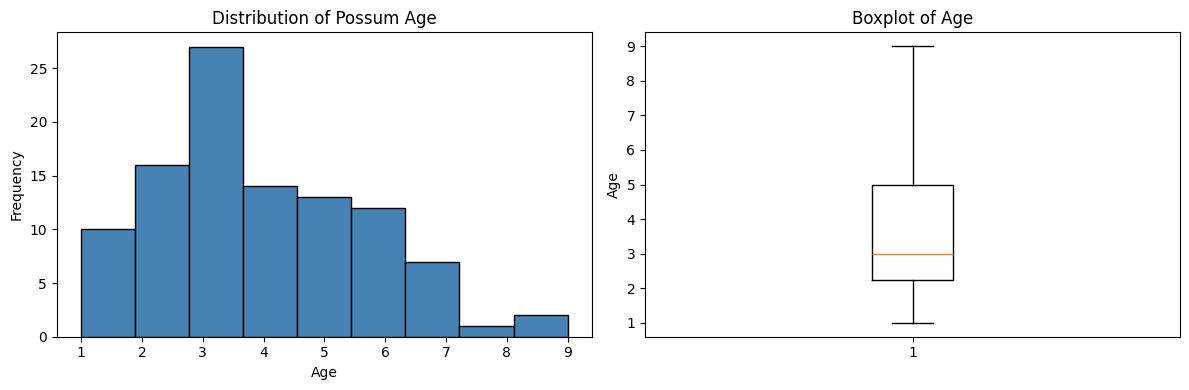

count    102.000000
mean       3.833333
std        1.909244
min        1.000000
25%        2.250000
50%        3.000000
75%        5.000000
max        9.000000
Name: age, dtype: float64


In [ ]:
##1
#Distribution of Target Variable (Age)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df["age"], bins=9, edgecolor="black", color="steelblue")
axes[0].set_title("Distribution of Possum Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Boxplot to spot outliers
axes[1].boxplot(df["age"], vert=True)
axes[1].set_title("Boxplot of Age")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.show()

print(df["age"].describe())

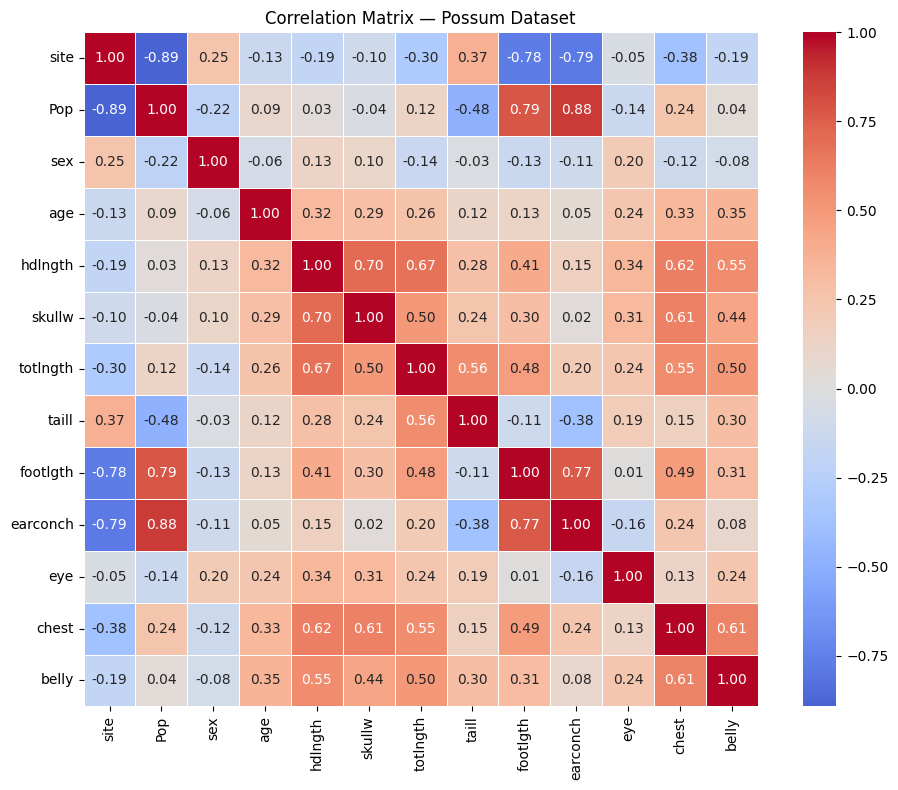

In [ ]:
##2
#Correlation Heatmap

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix — Possum Dataset")
plt.tight_layout()
plt.show()

In [22]:
# Print correlations with age specifically, sorted
print("Feature correlations with age:")
print(corr_matrix["age"].drop("age").sort_values(ascending=False))

Feature correlations with age:
belly       0.354298
chest       0.334209
hdlngth     0.319022
skullw      0.285107
totlngth    0.260280
eye         0.235553
footlgth    0.125261
taill       0.118241
Pop         0.086827
earconch    0.053405
sex        -0.064442
site       -0.131423
Name: age, dtype: float64


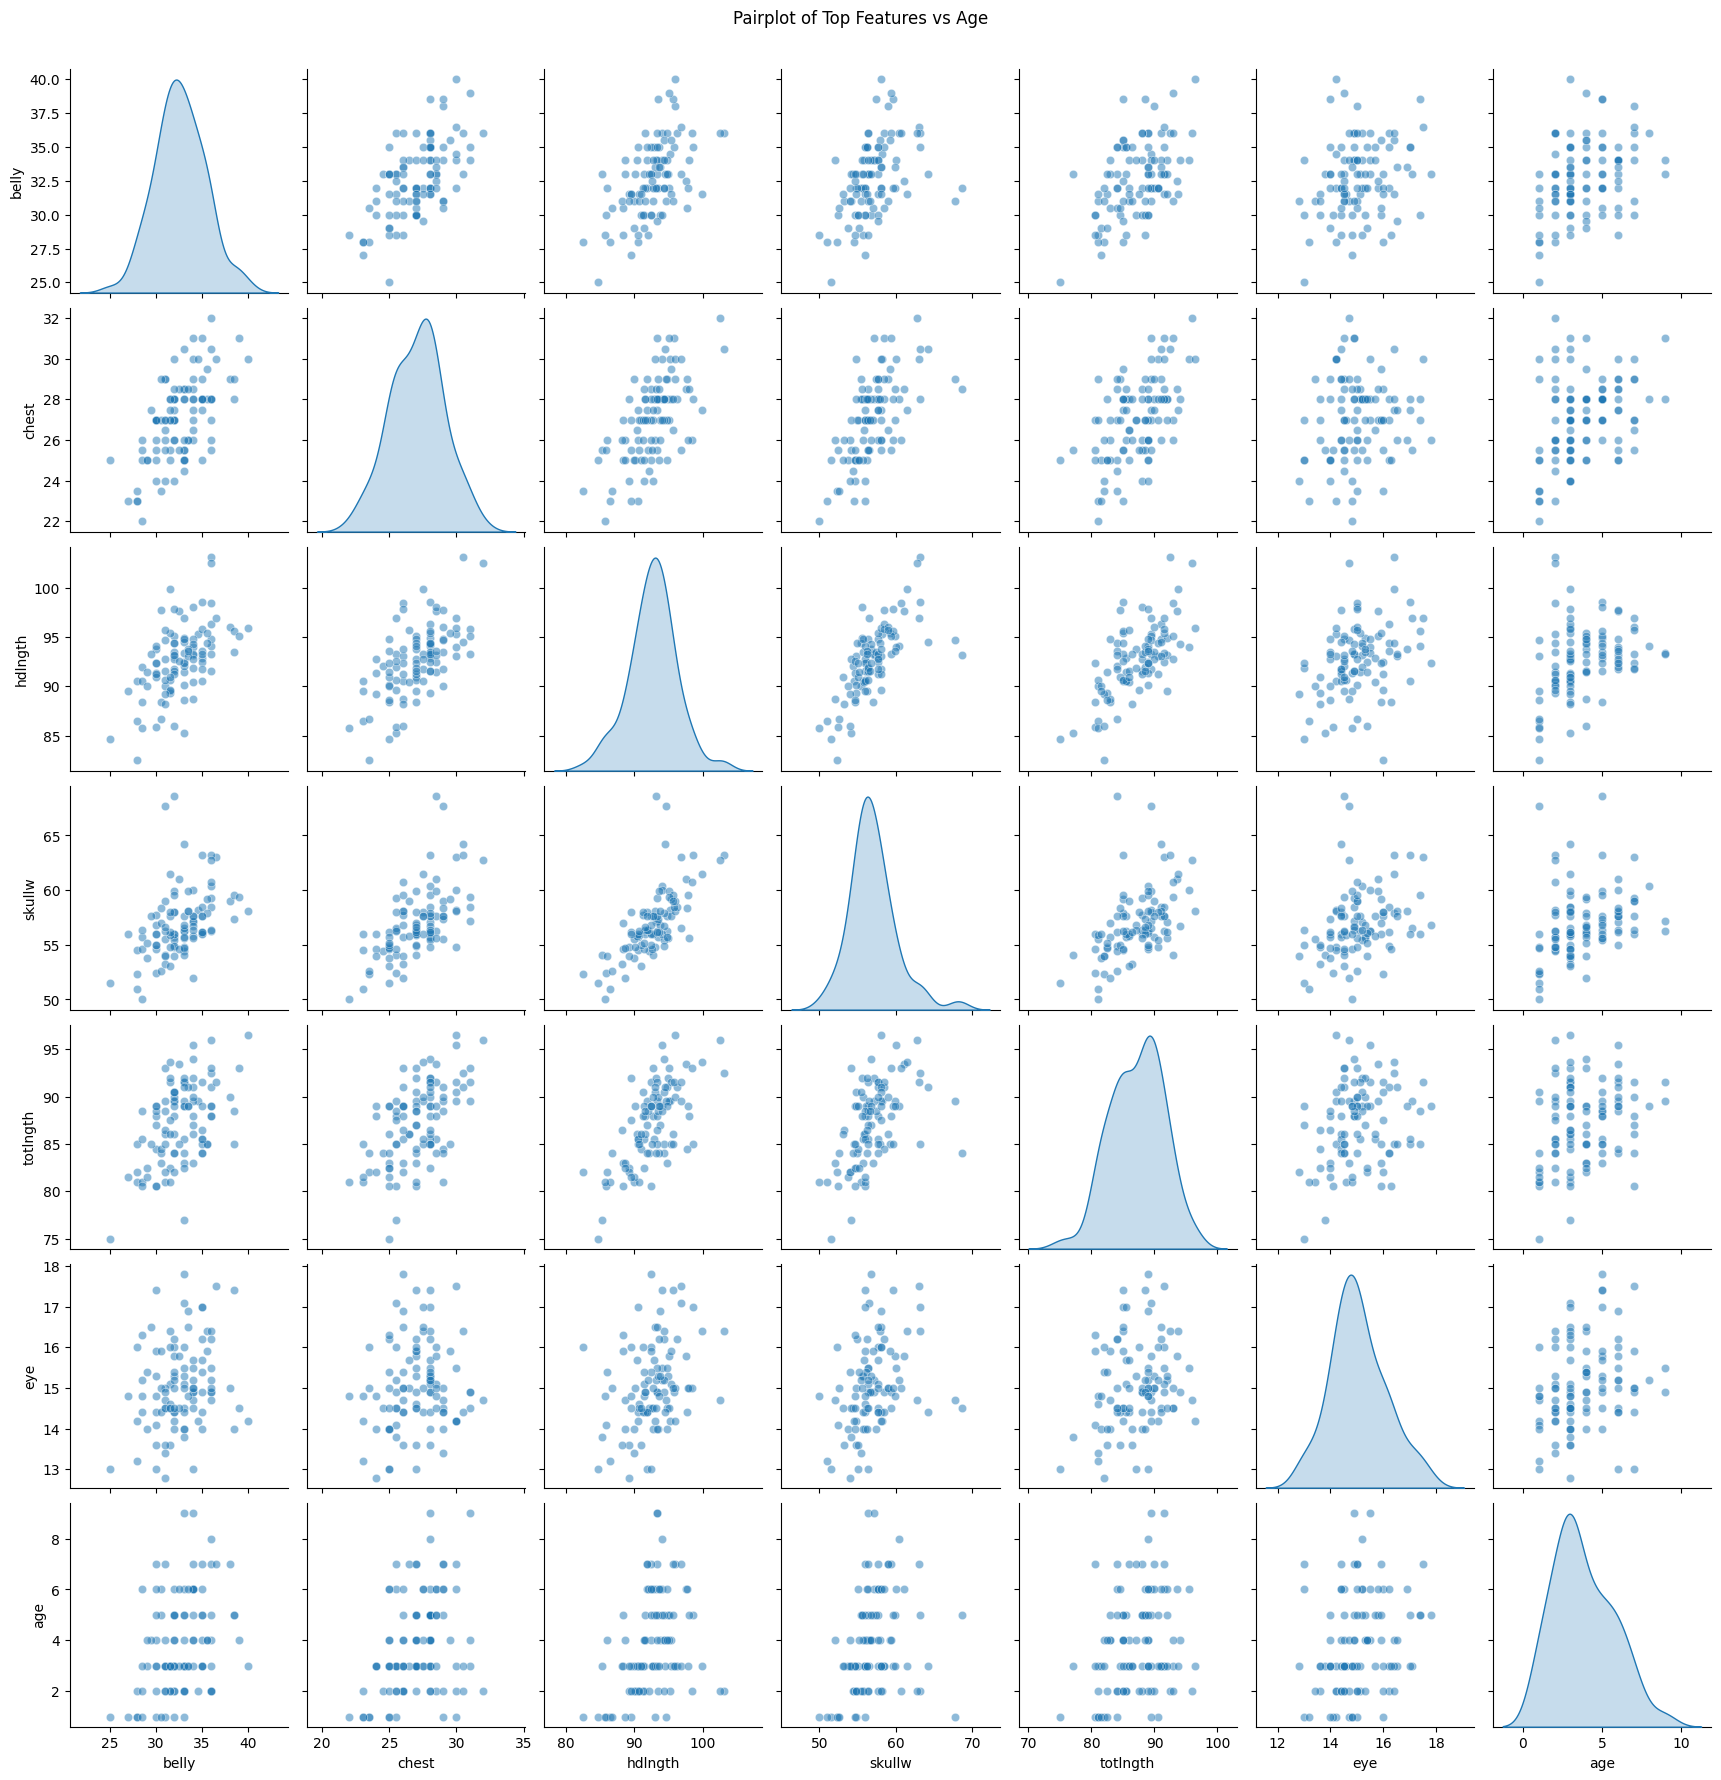

In [23]:
##3
#Pairplot of Top Correlated Features

# Select features most correlated with age (adjust threshold as needed)
top_features = corr_matrix["age"].drop("age").abs().sort_values(ascending=False)
top_cols = top_features[top_features > 0.2].index.tolist()

sns.pairplot(df[top_cols + ["age"]], hue=None, diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Top Features vs Age", y=1.02)
plt.show()

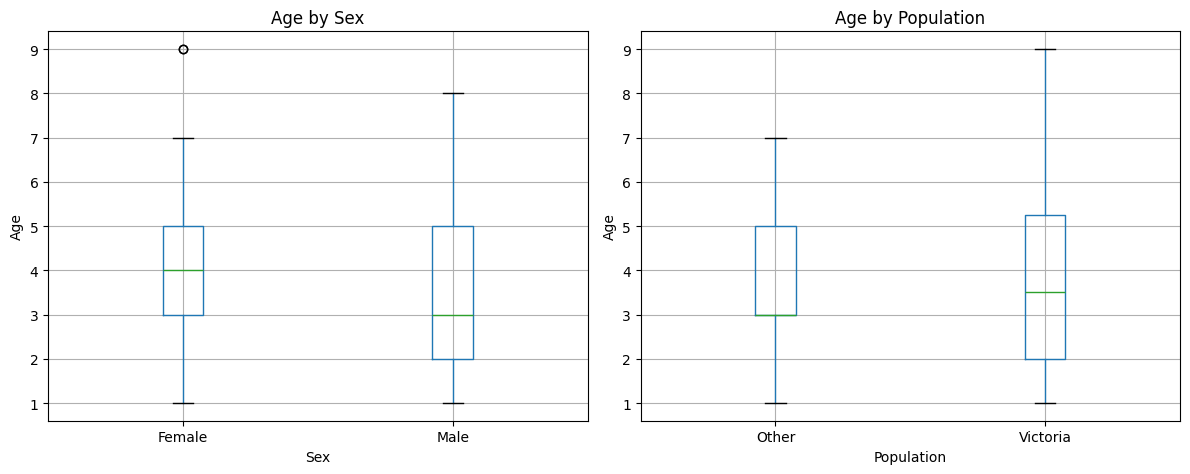

In [24]:
##4
#Age by Categorical Variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age by sex
sex_labels = {1: "Male", 0: "Female"}
df["sex_label"] = df["sex"].map(sex_labels)
df.boxplot(column="age", by="sex_label", ax=axes[0])
axes[0].set_title("Age by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Age")

# Age by population
pop_labels = {1: "Victoria", 0: "Other"}
df["pop_label"] = df["Pop"].map(pop_labels)
df.boxplot(column="age", by="pop_label", ax=axes[1])
axes[1].set_title("Age by Population")
axes[1].set_xlabel("Population")
axes[1].set_ylabel("Age")

plt.suptitle("")  # Suppress default suptitle from boxplot
plt.tight_layout()
plt.show()

# Drop helper label columns
df = df.drop(columns=["sex_label", "pop_label"])

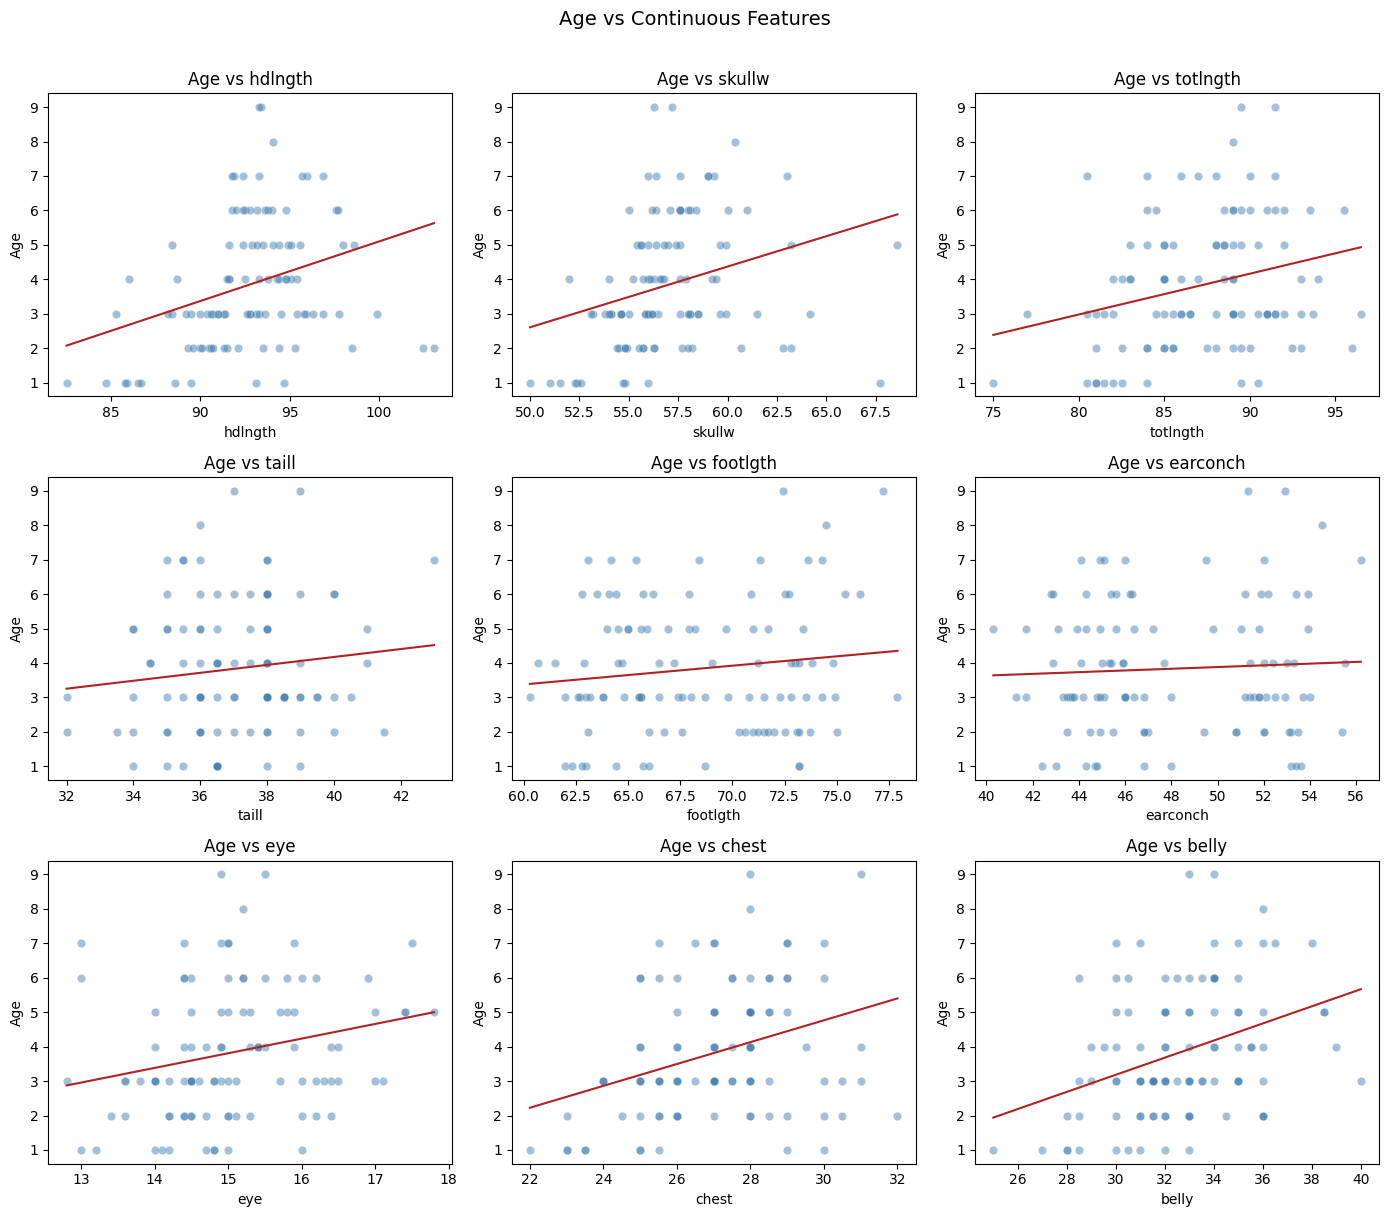

In [25]:
##5
#Scatter Plots: Age vs Continuous Features

continuous_features = ["hdlngth", "skullw", "totlngth", "taill", "footlgth", "earconch", "eye", "chest", "belly"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].scatter(df[col], df["age"], alpha=0.5, color="steelblue", edgecolors="white", linewidth=0.3)
    
    # Fit and plot a trend line
    m, b = np.polyfit(df[col], df["age"], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="firebrick", linewidth=1.5)
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Age")
    axes[i].set_title(f"Age vs {col}")

plt.suptitle("Age vs Continuous Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

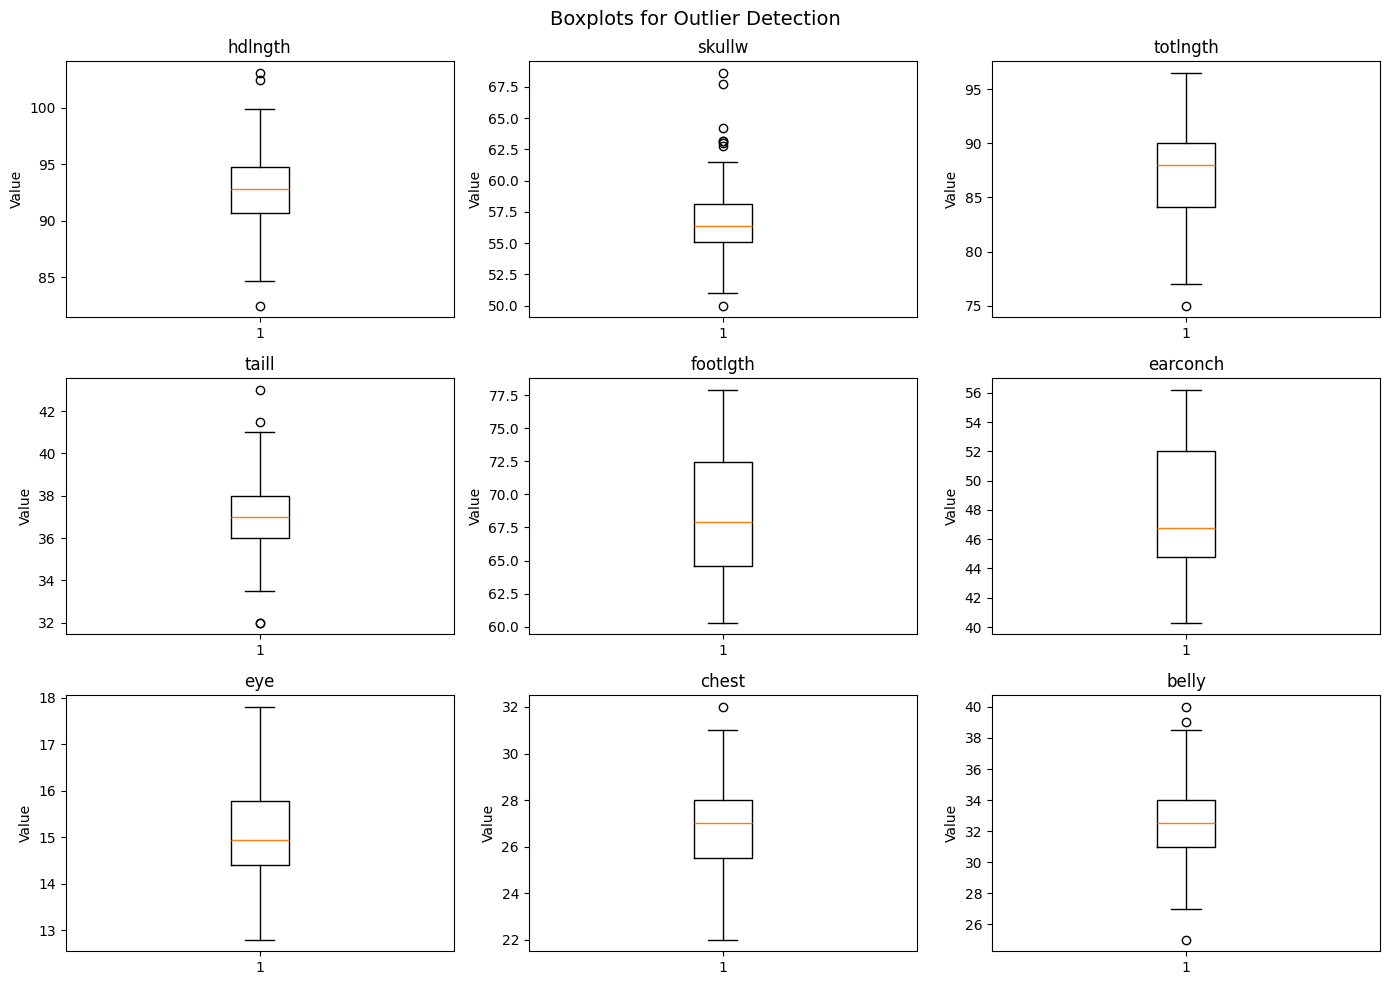

In [26]:
##6
#Outlier Detection with Boxplots

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.suptitle("Boxplots for Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
##7
#Summary Insights
print("=== EDA Summary ===\n")
print(f"Total observations (after cleaning): {df.shape[0]}")
print(f"Features: {df.shape[1] - 1} predictors + 1 target (age)\n")

print("Age distribution:")
print(df["age"].describe().round(2))

print("\nSex balance:")
print(df["sex"].value_counts().rename({1: "Male", 0: "Female"}))

print("\nPopulation balance:")
print(df["Pop"].value_counts().rename({1: "Victoria", 0: "Other"}))

print("\nTop 3 features correlated with age:")
print(corr_matrix["age"].drop("age").abs().sort_values(ascending=False).head(3))

=== EDA Summary ===

Total observations (after cleaning): 102
Features: 12 predictors + 1 target (age)

Age distribution:
count    102.00
mean       3.83
std        1.91
min        1.00
25%        2.25
50%        3.00
75%        5.00
max        9.00
Name: age, dtype: float64

Sex balance:
sex
Male      59
Female    43
Name: count, dtype: int64

Population balance:
Pop
Other       58
Victoria    44
Name: count, dtype: int64

Top 3 features correlated with age:
belly      0.354298
chest      0.334209
hdlngth    0.319022
Name: age, dtype: float64
